In [ ]:
import pandas as pd
import matplotlib.pyplot as plt #.pyplot for colors in the graphs
import seaborn as sns
from sklearn.linear_model import LinearRegression #(Linear regression library is owned by scikit learn (sklearn))
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor # for Decision tree regressor
from sklearn import tree # enables us to do the tree visualizations

In [ ]:
df_dec = pd.read_csv("/content/drive/MyDrive/archive/housing.csv")

In [ ]:
df_dec = df_dec.dropna()

In [ ]:
X = df_dec[['longitude', 'latitude', 'housing_median_age', 'total_rooms','total_bedrooms', 'population',
'households','median_income']]

#target variable
y = df_dec['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )

In [ ]:
df_dec.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


dt_regressor (this is a variable name, you can use anything) = DecisionTreeRegressor ().  creating an instanace
of a decision tree regressor from sklearn. inside the parenthesis are hyperparameters-settings that control how the
tree behaves.

     max depth = number of steps of a flowchart

     min_samples_split = y;  means you must have at least y things in a node (a node is a box in a tree/flowchart)

     min_samples_leaf = x;  the final step, the nodes (the box in a flowchart ), so the last boxes must have x items/ reasons in them for prediction.

If prediction is not good increase the max depth

A decision tree regressor works like a game of 20 questions it keeps asking yes/no questions to narrow down to a prediction.

In [ ]:
dt_regressor = DecisionTreeRegressor(
    max_depth = 10, #Limit how deep the tree can go, how many levels of splits; The yes and no question should not exceed 10 steps
    min_samples_split = 20, #Only split a group if it is big enough. Minimum samples required to split a node;
    #splitting points within the tree;
    #node must have at least 20 datapoints to even be consideredfor splitting
    min_samples_leaf = 10, #Minimum samples required at a leaf node;
    random_state = 42
)

dt_regressor.fit(X_train, y_train) #training the decision tree regressor using training data
#.fit is the backend computation how the model calculates for prediction

DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                      random_state=42)

In [ ]:
#make prediction for the train dataset
y_pred_train = dt_regressor.predict(X_train)
print(y_pred_train)

[221870.29245283 102065.13409962 244037.13100437 ... 345400.
 261352.63157895 251872.72727273]


In [ ]:
#create a DataFrame for actual vs predicted values on the train set
results_df = pd.DataFrame({'Actual': y_train, 'Predicted':y_pred_train})
display(results_df.head(10))

,Actual,Predicted
17727,227600.0,221870.292453
2057,110400.0,102065.134100
6453,248100.0,244037.131004
4619,305600.0,375100.250000
15266,214600.0,231400.897436
6823,227300.0,202709.318707
8384,177200.0,181845.454545
2758,84700.0,64100.000000
18143,451400.0,409121.714286
15621,500001.0,424580.400000


In [ ]:
y_pred_test = dt_regressor.predict(X_test)
print(y_pred_test)

[215201.53030303 188709.375      202709.3187067  ...  79421.76470588
 113330.76923077 131809.5505618 ]


In [ ]:
#create a DataFrame for actual vs predicted values on the train set
results_df = pd.DataFrame({'Actual': y_test, 'Predicted':y_pred_test})
display(results_df.head(10))

,Actual,Predicted
14416,245800.0,215201.530303
16383,137900.0,188709.375000
7731,218200.0,202709.318707
1410,220800.0,112925.352113
1335,170500.0,158175.342466
16260,75000.0,91215.862069
18011,269400.0,302928.607143
10086,228900.0,202709.318707
18294,500001.0,458230.200000
18733,80800.0,64023.865672


In [ ]:
#find R2 and MAE for both train and test dataset
train_r2 = r2_score(y_train, y_pred_train) # we are evaluating on the train model
test_r2 = r2_score(y_test, y_pred_test) # we are evaluating on the test model

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Training R2 Score:", round(train_r2, 4))
print("Test R2 score:", round(test_r2, 4))
print("Training MAE:", round(train_mae, 2))
print("Test MAE:", round(test_mae, 2))

Training R2 Score: 0.8054
Test R2 score: 0.7312
Training MAE: 34361.28
Test MAE: 40685.62


In [ ]:
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"Training R2 score: {train_r2: .4f}")
print(f"test R2 Score: {test_r2:.4f}")
print(f"Training MAE: {train_mae: .2f}")
print(f"Test MAE: {test_mae: .2f}")

Training R2 score:  0.8054
test R2 Score: 0.7312
Training MAE:  34361.28
Test MAE:  40685.62


Feature Importance : tells us how much each input variable (feature) contributes to the model's predictions.

In [ ]:
# feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_regressor.feature_importances_}).sort_values('importance', ascending = False) #dt_regressor.feature_importances is not a solved variable
    # it is a function inside the regression tree that shows the most important features or the features that affect the most in a model
#.sort_values is for sorting the values and it goes hand in hand ascending = False/True, sorting it by a particular feature
display(feature_importance)

,feature,importance
7,median_income,0.597315
0,longitude,0.171375
1,latitude,0.149376
2,housing_median_age,0.052824
5,population,0.011115
6,households,0.006720
4,total_bedrooms,0.006472
3,total_rooms,0.004802


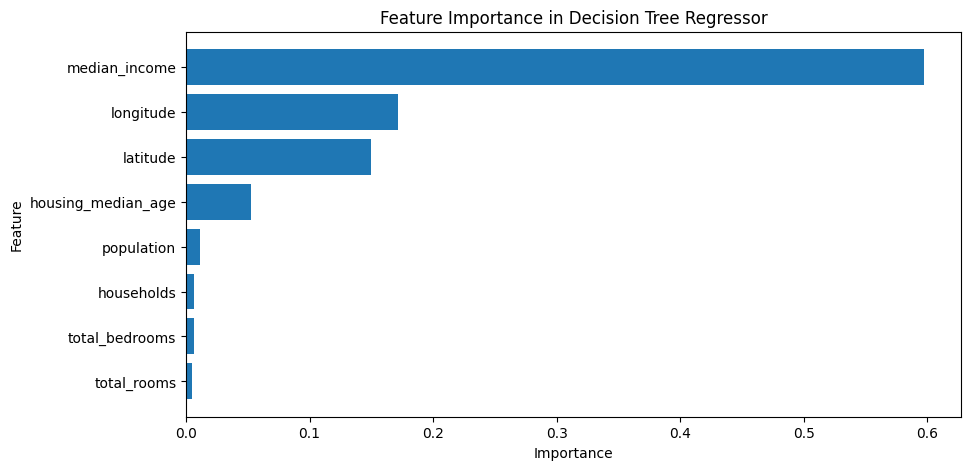

In [ ]:
sorted_importance = feature_importance.sort_values(by ='importance', ascending = True) #The 'by=' is not necessary, you can run it without it
# this fxn is to sort the feature_ importance variable from the previous code to descending order but opposite since the graph is horizontal
plt.figure(figsize =(10, 5))
plt.barh(sorted_importance['feature'], sorted_importance['importance'])#plt.barh gives horizontal bar chart; plt.barh(y,x); default color is blue,
#we didnt give it volor so it gave us the default color
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Decision Tree Regressor')
plt.show()

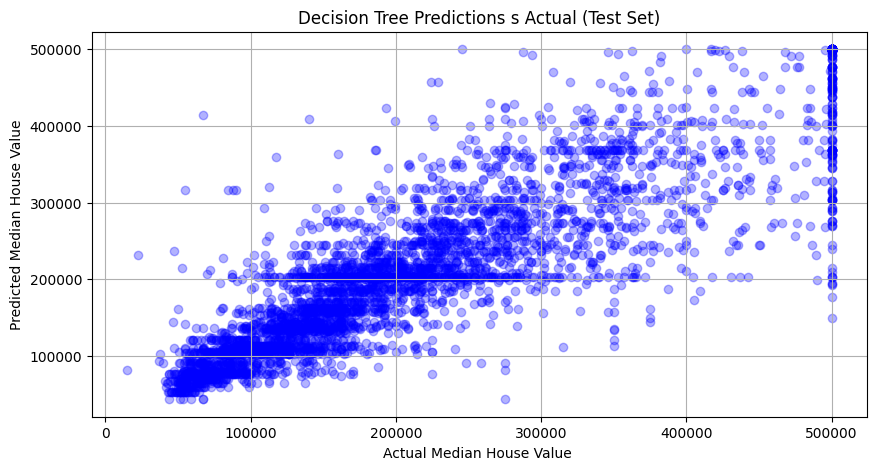

In [ ]:
#plot actual vs predicted values for the testing set
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_test, alpha = 0.3, color = 'blue')
plt.xlabel("Actual Median House Value ")
plt.ylabel("Predicted Median House Value")
plt.title("Decision Tree Predictions s Actual (Test Set)")
plt.grid(True)
plt.show()

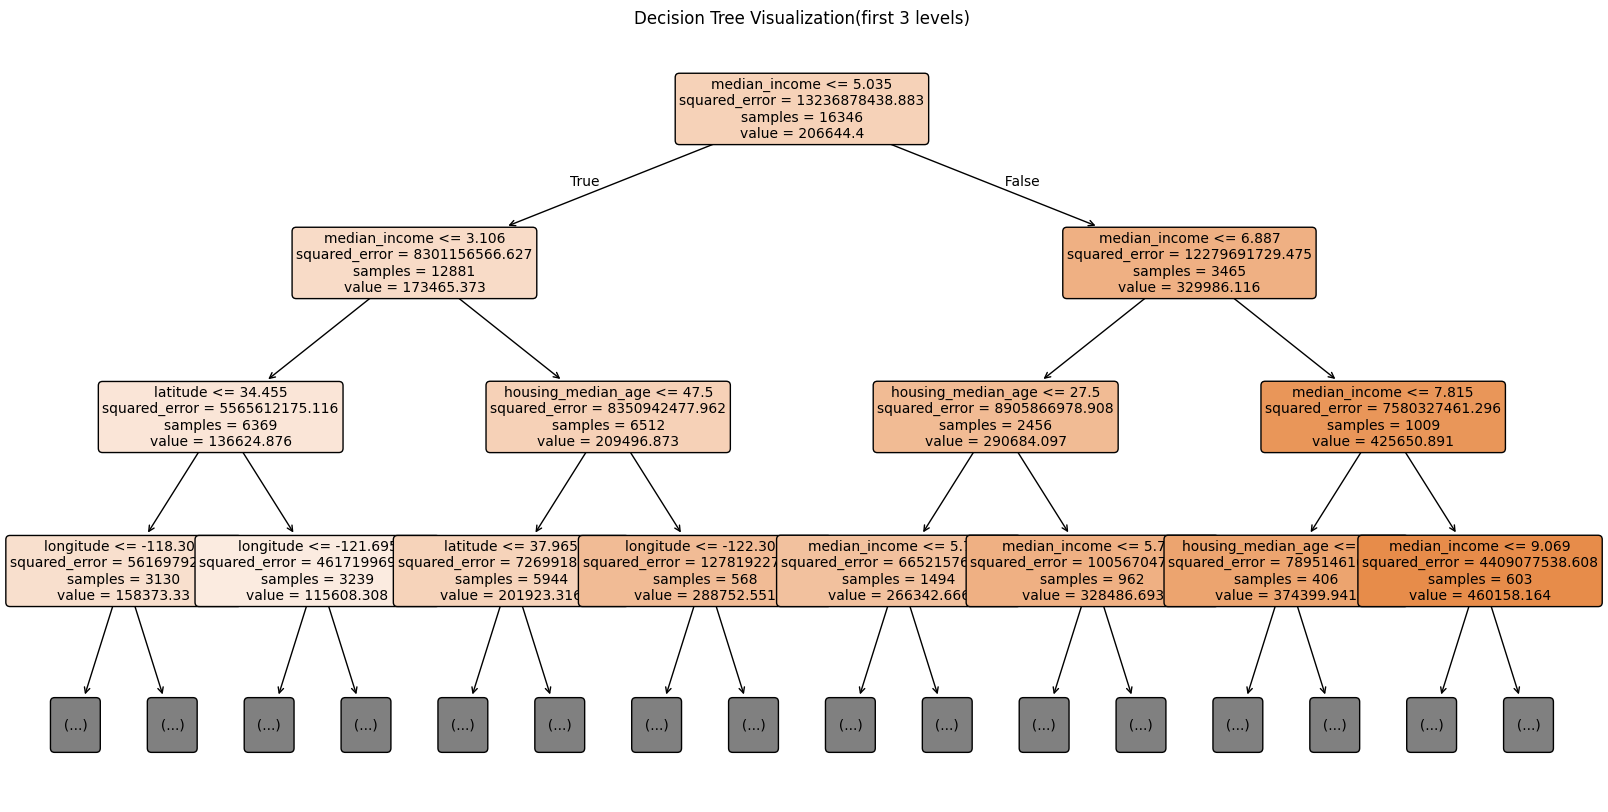

In [ ]:
#Visualize a small portion of the tree (first few levels)
plt.figure(figsize= (20,10)) # bigger fit for the tree/flowchart
features = X.columns #Define features using the Dataframe columns, we want to include the feature names inside the boxes of our tree
tree.plot_tree(dt_regressor, #dt_regressor is our model name
               feature_names = features, #feautures is a variable name for
               max_depth = 3, #We only want 4 steps, step 0, step 1, step 2 and step 3
               filled = True, #fill the boxes with color based on the output values, the oones with higher values will be darker
               rounded = True, #rounding the edge of the node
               fontsize = 10) #size of the letters
# tree.plot_tree is a fxn used to plot/draw a tree(flow chart) diagram using the sklearn import tree library
#tree will use the most important feature to start the split for the tree(dataset)
plt.title('Decision Tree Visualization(first 3 levels)')
plt.show()